In [29]:
import gym
import collections
import numpy as np
from operator import itemgetter

def discretize(observation, bins):
    discrete_obs = [np.max(np.digitize(obs, bins[i])-1,0) for i, obs in enumerate(observation)]
    return tuple(discrete_obs)

def choose_action(Q, state, epsilon, env):
    if np.random.rand() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])


def update_Q(Q, alpha, state, action, reward, gamma, next_state):


    next_state_q = np.max(Q[next_state])
    state_q = Q[state+(action,)]
    Q[state+(action,)] = state_q + alpha * (reward + gamma * next_state_q - state_q)


def train(env, episodes=7000, gamma=0.99, epsilon=1.0, epsilon_decay=0.995, epsilon_min=0.01, alpha=0.1):
    num_bins = [6, 12, 12, 24]  # Define the number of bins for each observation
    bins = [
        np.linspace(-2.4, 2.4, num_bins[0]), 
        np.linspace(-5, 5, num_bins[1]), 
        np.linspace(-0.418, 0.418, num_bins[2]),
        np.linspace(-5, 5, num_bins[3])
    ]

    Q = np.random.uniform(low=0, high=1, size=(num_bins + [env.action_space.n]))
    rewards = []
    avg_reward = []
    for episode in range(episodes):
        observation = env.reset()[0]
        state = discretize(tuple(observation), bins)
        total_reward = 0
        done = False

        while not done:
            action = choose_action(Q, state, epsilon, env)
            obs, reward, done, i, j = env.step(action)
            next_state = discretize(obs, bins)
            update_Q(Q, alpha, state, action, reward, gamma, next_state)
            state = next_state
            total_reward += reward

        rewards.append(total_reward)

        epsilon = max(epsilon_min, epsilon * epsilon_decay)


        if episode >= 100 and np.mean(rewards[-100:]) >= 195.0:
            avg_reward.append(np.mean(rewards[-100:]))
            print(f"Solved in {episode + 1} episodes! and avg reward (last 100 episodes): {np.mean(rewards[-100:]):.2f} ")
            break

        if (episode + 1) % 100 == 0:
            avg_reward.append(np.mean(rewards[-100:]))
            print(f"Episode {episode + 1}, Average Reward (last 100 episodes): {np.mean(rewards[-100:]):.2f}")
            
    return avg_reward

env = gym.make('CartPole-v1')

avg_reward = train(env)

Episode 100, Average Reward (last 100 episodes): 31.44
Episode 200, Average Reward (last 100 episodes): 34.35
Episode 300, Average Reward (last 100 episodes): 52.70
Episode 400, Average Reward (last 100 episodes): 106.14
Episode 500, Average Reward (last 100 episodes): 108.66
Episode 600, Average Reward (last 100 episodes): 111.70
Episode 700, Average Reward (last 100 episodes): 116.16
Episode 800, Average Reward (last 100 episodes): 108.37
Episode 900, Average Reward (last 100 episodes): 117.81
Episode 1000, Average Reward (last 100 episodes): 119.73
Episode 1100, Average Reward (last 100 episodes): 119.85
Episode 1200, Average Reward (last 100 episodes): 120.80
Episode 1300, Average Reward (last 100 episodes): 121.47
Episode 1400, Average Reward (last 100 episodes): 115.41
Episode 1500, Average Reward (last 100 episodes): 105.84
Episode 1600, Average Reward (last 100 episodes): 117.86
Episode 1700, Average Reward (last 100 episodes): 120.03
Episode 1800, Average Reward (last 100 epis

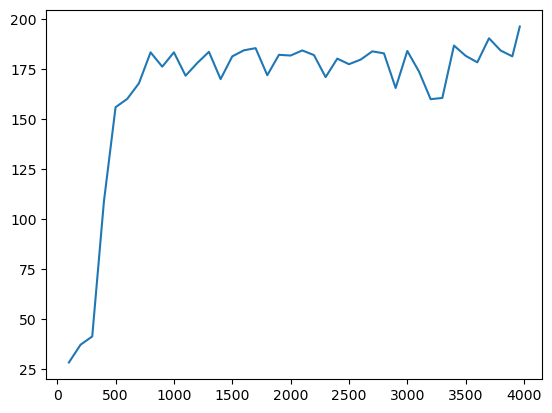

In [28]:
import matplotlib.pyplot as plt
x= np.arange(100,4001,100)
x[-1] = 3964
plt.plot(x,avg_reward)
plt.show()